# Analyzing PGA Tour Data from 2001-2025

### Load the Data

In [43]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cviaxmiwnptr/pga-tour-results-2001-to-may-2024")

print("Path to dataset files:", path)

Path to dataset files: /Users/johannalealudviksdottir/.cache/kagglehub/datasets/cviaxmiwnptr/pga-tour-results-2001-to-may-2024/versions/4


In [44]:
import os
import pandas as pd

In [45]:
# List files in the dataset directory
print("Files in dataset directory:", os.listdir(path))

Files in dataset directory: ['pga_results_2001-2025.tsv']


In [46]:
# Load the dataset
file_path = os.path.join(path, "pga_results_2001-2025.tsv")

# Load the dataset into a DataFrame
df = pd.read_csv(file_path, sep="\t")

### Inspect the Dataset

In [47]:
df.shape

(148883, 15)

In [48]:
df.columns

Index(['season', 'start', 'end', 'tournament', 'location', 'position', 'name',
       'score', 'round1', 'round2', 'round3', 'round4', 'total', 'earnings',
       'fedex_points'],
      dtype='str')

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148883 entries, 0 to 148882
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   season        148883 non-null  int64  
 1   start         148883 non-null  str    
 2   end           148883 non-null  str    
 3   tournament    148883 non-null  str    
 4   location      144221 non-null  str    
 5   position      148883 non-null  str    
 6   name          148883 non-null  str    
 7   score         148883 non-null  str    
 8   round1        145429 non-null  float64
 9   round2        144734 non-null  float64
 10  round3        86052 non-null   float64
 11  round4        80863 non-null   float64
 12  total         147158 non-null  float64
 13  earnings      147462 non-null  float64
 14  fedex_points  100365 non-null  float64
dtypes: float64(7), int64(1), str(7)
memory usage: 17.0 MB


In [50]:
df.describe()

,season,round1,round2,round3,round4,total,earnings,fedex_points
count,148883.00000,145429.000000,144734.000000,86052.000000,80863.000000,147158.000000,1.474620e+05,100365.000000
mean,2012.62443,71.224804,71.132402,70.687236,70.898990,223.120184,5.355343e+04,52.731649
std,7.31373,3.386642,3.470568,3.313970,3.338957,70.115175,1.945755e+05,251.546164
min,2001.00000,4.000000,11.000000,8.000000,22.000000,-19.000000,0.000000e+00,0.000000
25%,2006.00000,69.000000,69.000000,68.000000,69.000000,147.000000,0.000000e+00,0.000000
50%,2012.00000,71.000000,71.000000,71.000000,71.000000,271.000000,9.180000e+03,0.000000
75%,2019.00000,73.000000,73.000000,73.000000,73.000000,282.000000,3.851100e+04,35.000000
max,2025.00000,92.000000,94.000000,88.000000,89.000000,464.000000,1.800000e+07,12500.000000


First 5 rows of the dataframe:

In [51]:
df.head()

,season,start,end,tournament,location,position,name,score,round1,round2,round3,round4,total,earnings,fedex_points
0,2001,2001-01-11,2001-01-14,Touchstone Energy Tucson Open,Omni Tucson National Golf Resort and Spa - Tuc...,1,Garrett Willis,-15,71.0,69.0,64.0,69.0,273.0,540000.0,NaN
1,2001,2001-01-11,2001-01-14,Touchstone Energy Tucson Open,Omni Tucson National Golf Resort and Spa - Tuc...,2,Kevin Sutherland,-14,67.0,72.0,67.0,68.0,274.0,324000.0,NaN
2,2001,2001-01-11,2001-01-14,Touchstone Energy Tucson Open,Omni Tucson National Golf Resort and Spa - Tuc...,T3,Bob Tway,-13,73.0,69.0,67.0,66.0,275.0,174000.0,NaN
3,2001,2001-01-11,2001-01-14,Touchstone Energy Tucson Open,Omni Tucson National Golf Resort and Spa - Tuc...,T3,Geoff Ogilvy,-13,67.0,72.0,68.0,68.0,275.0,174000.0,NaN
4,2001,2001-01-11,2001-01-14,Touchstone Energy Tucson Open,Omni Tucson National Golf Resort and Spa - Tuc...,T5,K.J. Choi,-12,70.0,70.0,70.0,66.0,276.0,105375.0,NaN


In [52]:
df.dtypes

season            int64
start               str
end                 str
tournament          str
location            str
position            str
name                str
score               str
round1          float64
round2          float64
round3          float64
round4          float64
total           float64
earnings        float64
fedex_points    float64
dtype: object

In [53]:
df.duplicated().sum()


np.int64(7)

### Inspecting Missing Values
There are a lot of missing values, especially for **round 3** and **round 4** because players miss the cut, then there are also missing values for **FedEx Points** because players don't get points until they play in at least one tournament to get points. There are also some missing data from **round1** and **2**, which could be because players who are registered or planned to play in tournaments don't show. There are also some missing **locations** and **earnings**

In [54]:
missing_values = df.isnull().sum()
print(missing_values)

season              0
start               0
end                 0
tournament          0
location         4662
position            0
name                0
score               0
round1           3454
round2           4149
round3          62831
round4          68020
total            1725
earnings         1421
fedex_points    48518
dtype: int64


In [55]:
df.isnull().sum().sort_values(ascending=False)

round4          68020
round3          62831
fedex_points    48518
location         4662
round2           4149
round1           3454
total            1725
earnings         1421
season              0
start               0
end                 0
tournament          0
position            0
name                0
score               0
dtype: int64

### Data Cleaning & Transforming

In [56]:
# Convert start/end dates to datetime:
df["start"] = pd.to_datetime(df["start"], errors="coerce")
df["end"] = pd.to_datetime(df["end"], errors="coerce")

In [57]:
# Change position column from string to numeric
df["position"] = df["position"].astype(str).str.replace("T", "")
df["position"] = pd.to_numeric(df["position"], errors="coerce")

In [58]:
# Change score column from string to numeric
df["score"] = pd.to_numeric(df["score"], errors="coerce")
# Under par indicator
df["under_par"] = df["score"] < 0

In [69]:
df = df[df["rounds_played"] > 0]

In [ ]:
# Create useful columns for analysis

# Extract year, month, day, and day of week from start date
df["year"] = df["start"].dt.year
df["month"] = df["start"].dt.month
df["day"] = df["start"].dt.day
df["day_of_week"] = df["start"].dt.day_name()
# Calculate rounds played
df["rounds_played"] = df[["round1", "round2", "round3", "round4"]].notnull().sum(axis=1)
# Calculate average score per round
df["average_score_per_round"] = df["total"] / df["rounds_played"]
# Top 10 finish
df["top10"] = df["position"] <= 10
# Win indicator
df["win"] = df["position"] == 1
# Made cut indicator
df["made_cut"] = df["rounds_played"] >= 3
# Earnings per round
df["earnings_per_round"] = df["earnings"] / df["rounds_played"]
# Score consistency (standard deviation of round scores)
df["score_consistency"] = df[["round1", "round2", "round3", "round4"]].std(axis=1)
# Bounce back potential 
df["bounce_back"] = df["round2"] < df["round1"]
# Performance under pressure (round 4 score vs average of round 1-3)
df["performance_under_pressure"] = df["round4"] - df[["round1", "round2", "round3"]].mean(axis=1)
# Course difficulty (average score relative to par for the course)
df["course_difficulty"] = df.groupby("tournament")["average_score_per_round"].transform("mean")

## Descriptive Analysis

In [97]:
df.shape

(145430, 30)

In [71]:
# Average placement per season
season_avg = df.groupby("name")["position"].mean()
print(season_avg.head())

name
A.J. Ewart         1.000000
A.J. Ewart (a)          NaN
A.J. McInerney    36.500000
Aaron Baddeley    36.394137
Aaron Barber      37.947368
Name: position, dtype: float64


In [74]:
# Number of made cuts per player
made_cuts = df.groupby("name")["made_cut"].sum()
print(made_cuts.head())

name
A.J. Ewart          1
A.J. Ewart (a)      0
A.J. McInerney      2
Aaron Baddeley    315
Aaron Barber       22
Name: made_cut, dtype: int64


In [ ]:
# Average score by course
course_avg_score = df.groupby("tournament")["average_score_per_round"].mean()
print(course_avg_score.head())

tournament
100th Western Open presented by Golf Digest    72.896104
2017 Masters Tournament                        74.529570
2018 Masters Tournament                        73.701149
2019 Masters Tournament                        72.324713
2020 Masters Tournament                        72.192308
Name: average_score_per_round, dtype: float64


In [77]:
# Amount of players who made the cut per tournament
print("Number of players who made the cut per tournament:")
cut_counts = df.groupby("tournament")["made_cut"].sum()
print(cut_counts.head())

print("Percentage of players who made the cut per tournament:")
cut_count_percentage = cut_counts / df.groupby("tournament")["name"].nunique() * 100
print(cut_count_percentage.head())

Number of players who made the cut per tournament:
tournament
100th Western Open presented by Golf Digest    70
2017 Masters Tournament                        53
2018 Masters Tournament                        53
2019 Masters Tournament                        65
2020 Masters Tournament                        60
Name: made_cut, dtype: int64
Percentage of players who made the cut per tournament:
tournament
100th Western Open presented by Golf Digest    45.751634
2017 Masters Tournament                        56.989247
2018 Masters Tournament                        60.919540
2019 Masters Tournament                        74.712644
2020 Masters Tournament                        65.934066
dtype: float64


In [91]:
best_players = (
    df.groupby("name")
    .agg(
        avg_finish = ("position", "mean"),
        wins = ("win", "sum"),
        top10s = ("top10", "sum"),
        tournaments_played = ("tournament", "count"),
        made_cuts = ("made_cut", "sum"),
        avg_score = ("average_score_per_round", "mean"),
        total_earnings = ("earnings", "sum")
    )
)

highest_average_finish = best_players.query("tournaments_played >= 20").sort_values("avg_finish")


In [98]:
print(best_players.sort_values("top10s", ascending=False).head(10))

                avg_finish  wins  top10s  tournaments_played  made_cuts  \
name                                                                      
Tiger Woods      18.195833    56     141                 272        243   
Jim Furyk        20.498534    12     136                 423        344   
Phil Mickelson   26.484848    28     131                 446        367   
Rory McIlroy     16.086580    27     129                 262        232   
Vijay Singh      23.810976    25     124                 438        332   
Justin Rose      22.567164    12     122                 433        336   
Dustin Johnson   20.249012    23     114                 309        254   
Matt Kuchar      25.565432     8     114                 558        414   
Adam Scott       24.170588    15     112                 406        342   
Jason Day        22.540146    11      95                 356        277   

                avg_score  total_earnings  
name                                       
Tiger Woods

In [94]:
print("Top 10 players based on average finish (only those with 20+ tournaments):")
print(highest_average_finish[["avg_finish"]].head(10))

Top 10 players based on average finish (only those with 20+ tournaments):
                   avg_finish
name                         
Scottie Scheffler   13.769231
Rory McIlroy        16.086580
Jon Rahm            16.148148
Tiger Woods         18.195833
Xander Schauffele   18.982143
Patrick Cantlay     20.098160
Justin Thomas       20.107477
Dustin Johnson      20.249012
Ludvig Åberg        20.255319
Jim Furyk           20.498534


In [90]:
top_winners = (
    best_players.query("tournaments_played >= 20").sort_values("wins", ascending=False).head(10)
)
print("Top 10 players by wins (20+ tournaments):")
print(top_winners[["wins", "avg_finish", "total_earnings"]])

Top 10 players by wins (20+ tournaments):
                   wins  avg_finish  total_earnings
name                                               
Tiger Woods          56   18.195833    9.747318e+07
Phil Mickelson       28   26.484848    8.166861e+07
Rory McIlroy         27   16.086580    1.406165e+08
Vijay Singh          25   23.810976    5.578596e+07
Dustin Johnson       23   20.249012    8.989216e+07
Scottie Scheffler    20   13.769231    1.055595e+08
Justin Thomas        16   20.107477    8.372542e+07
Adam Scott           15   24.170588    7.033692e+07
Jordan Spieth        14   21.265560    6.714210e+07
Hideki Matsuyama     13   21.313559    6.556000e+07


In [ ]:
# Players with the most years on tour
years_on_tour = (df.groupby("name")["season"].nunique().sort_values(ascending=False))
print(years_on_tour.head(10))

name
Luke Donald        25
Mike Weir          25
Shaun Micheel      25
Charley Hoffman    25
Justin Rose        25
Phil Mickelson     25
Matt Kuchar        25
Sergio Garcia      25
Jonathan Byrd      25
Stewart Cink       25
Name: season, dtype: int64


## Descriptive Analytics for Specific Players

### Jordan Spieth

In [116]:
print(df[df["name"] == "Jordan Spieth"].sort_values("score")[["year", "position", "tournament", "score", "total", "bounce_back"]].head())

        year  position                       tournament  score  total  \
92985   2016       1.0  Hyundai Tournament of Champions  -30.0  262.0   
137584  2024       3.0                       The Sentry  -27.0  265.0   
87174   2014       1.0             Hero World Challenge  -26.0  262.0   
128316  2022       2.0                AT&T Byron Nelson  -25.0  263.0   
90724   2015       1.0               John Deere Classic  -20.0  264.0   

        bounce_back  
92985          True  
137584        False  
87174         False  
128316         True  
90724          True  


### Tiger Woods

In [115]:
print(df[df["name"] == "Tiger Woods"].sort_values("score")[["year", "position", "tournament", "score", "total", "bounce_back"]].head())

       year  position                                    tournament  score  \
4866   2001       1.0                          WGC-NEC Invitational  -48.0   
12359  2002       1.0             WGC-American Express Championship  -25.0   
27431  2005       1.0                    Ford Championship at Doral  -24.0   
37058  2006       1.0                                    Buick Open  -24.0   
44133  2007       1.0  THE TOUR Championship presented by Coca-Cola  -23.0   

       total  bounce_back  
4866   268.0        False  
12359  263.0        False  
27431  264.0        False  
37058  264.0        False  
44133  257.0         True  


### Scottie Scheffler

In [114]:
print(df[df["name"] == "Scottie Scheffler"].sort_values("score")[["year", "position", "tournament", "score", "total", "bounce_back"]].head())

        year  position               tournament  score  total  bounce_back
145460  2025       1.0  THE CJ CUP Byron Nelson  -31.0  253.0        False
142055  2024       1.0        TOUR Championship  -30.0  264.0        False
143099  2024       1.0     Hero World Challenge  -25.0  263.0         True
137590  2024       5.0               The Sentry  -25.0  267.0         True
116282  2020       3.0     The American Express  -23.0  265.0         True


## Visualizations

### Top 10 Players by Wins

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

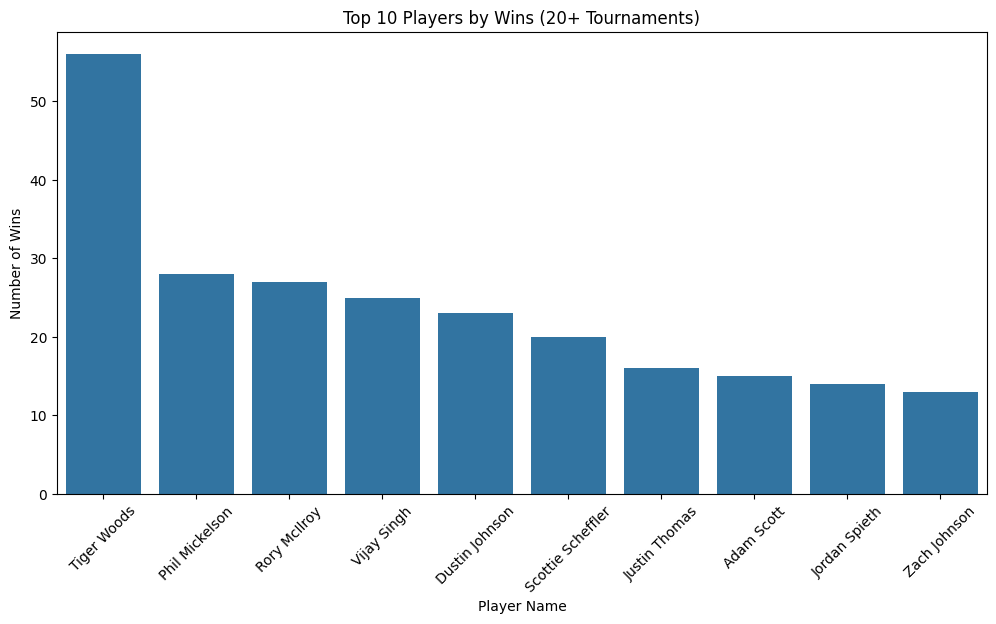

In [119]:
plt.figure(figsize=(12, 6))
sns.barplot(x="name", y="wins", data=best_players.sort_values("wins", ascending=False).head(10))
plt.title("Top 10 Players by Wins (20+ Tournaments)")
plt.xlabel("Player Name")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)
plt.show()

### Top 10 Career Earnings

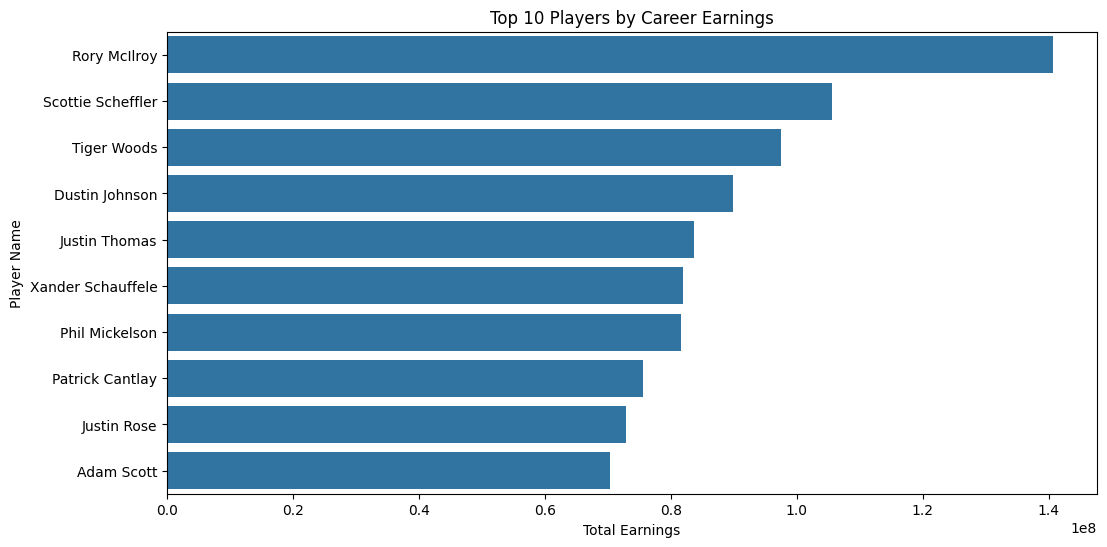

In [121]:
plt.figure(figsize=(12, 6))
sns.barplot(data=best_players.sort_values("total_earnings", ascending=False).head(10), x="total_earnings", y="name")
plt.title("Top 10 Players by Career Earnings")
plt.xlabel("Total Earnings")
plt.ylabel("Player Name")
plt.show()

### Hardest Tournaments

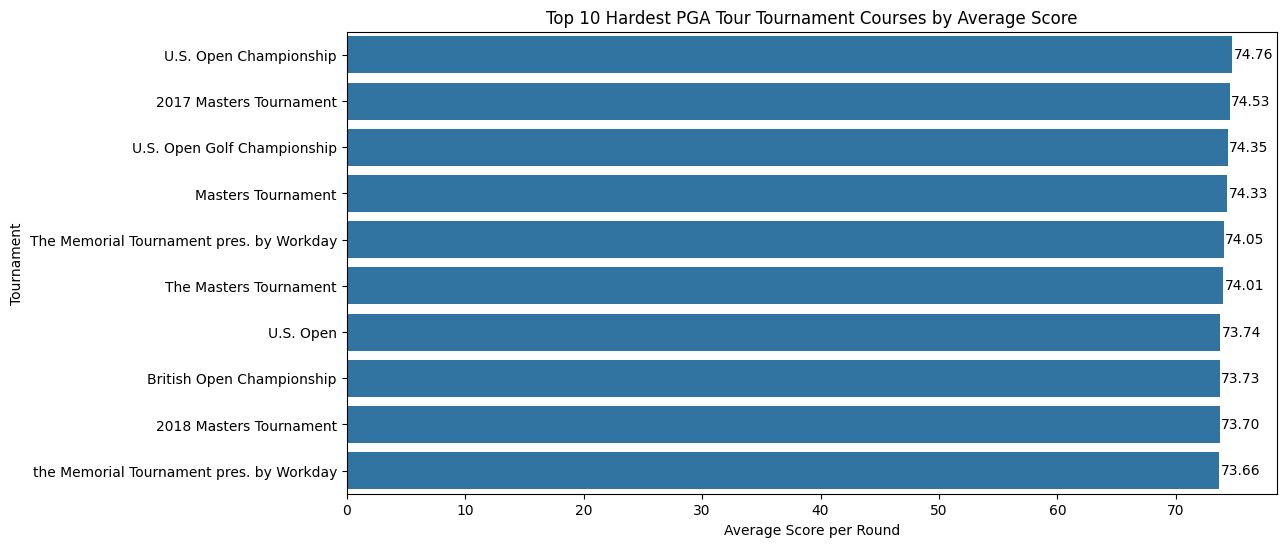

In [133]:
df["average_score_per_round"] = df[["round1", "round2", "round3", "round4"]].mean(axis=1)

hardest_courses =(
    df.groupby("tournament")["average_score_per_round"].mean().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=hardest_courses.values, y=hardest_courses.index)
# Add value labels to bars
for i, v in enumerate(hardest_courses.values):
    ax.text(
        v + 0.1,          # slightly to the right of bar
        i,                # y-position
        f"{v:.2f}",       # format to 2 decimals
        va="center"
    )
plt.title("Top 10 Hardest PGA Tour Tournament Courses by Average Score")
plt.xlabel("Average Score per Round")
plt.ylabel("Tournament")
plt.show()